# 27 · 拆 Claude Code 的 Agent 设计 + Trace 可视化

> **学习目标**：把 Claude Code（你正在用的这个 CLI）当成「生产 Agent 案例研究」—— 看它的工具列表 / 工具分类 / loop 风格。然后写一个 trace 可视化器，把 25/26 号 notebook 的 Agent trace 画成时间线。
>
> **预备**：25、26 跑过。
>
> **为什么重要**：Claude Code 是「最容易研究的生产级 Agent」—— 你能直接看它的 tool 命名、permission 设计、sub-agent 使用方式。比看 LangChain 文档实在 10 倍。

In [1]:
import json, time
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1. Claude Code 的工具盘点（推断自 system reminder）

**怎么知道这些**：在 Claude Code 里说「列出你所有可用工具」就能看到。下面是 2026-06 的快照（版本不同会变）。

**注意**：以下是 Claude Code **本身**的工具（写 / 编辑 / 搜文件等），跟你自己定义的 Agent 工具是两层不同的东西。

In [2]:
CLAUDE_CODE_TOOLS = [
    # 文件操作
    {'name': 'Read',           'category': 'file',   'side_effect': False, 'desc': '读文件（含图片、PDF、ipynb）'},
    {'name': 'Write',          'category': 'file',   'side_effect': True,  'desc': '写入新文件 / 完全覆盖'},
    {'name': 'Edit',           'category': 'file',   'side_effect': True,  'desc': '编辑现有文件（exact match 替换）'},
    {'name': 'NotebookEdit',   'category': 'file',   'side_effect': True,  'desc': '编辑 .ipynb cell'},
    # 搜索 / 发现
    {'name': 'Glob',           'category': 'search', 'side_effect': False, 'desc': '按模式找文件'},
    {'name': 'Grep',           'category': 'search', 'side_effect': False, 'desc': '搜内容（ripgrep）'},
    # 执行
    {'name': 'Bash',           'category': 'exec',   'side_effect': True,  'desc': '执行 shell 命令'},
    {'name': 'TaskOutput',     'category': 'exec',   'side_effect': False, 'desc': '获取后台任务输出'},
    {'name': 'TaskStop',       'category': 'exec',   'side_effect': True,  'desc': '停止后台任务'},
    # 协作
    {'name': 'Agent',          'category': 'agent',  'side_effect': False, 'desc': 'Spawn 子 Agent（隔离上下文）'},
    {'name': 'AskUserQuestion','category': 'agent',  'side_effect': False, 'desc': '问用户问题'},
    {'name': 'TodoWrite',      'category': 'agent',  'side_effect': False, 'desc': '维护任务列表'},
    # Skill / 计划
    {'name': 'Skill',          'category': 'skill',  'side_effect': False, 'desc': '调用 Skill'},
    {'name': 'EnterPlanMode',  'category': 'skill',  'side_effect': False, 'desc': '进入只读规划模式'},
    {'name': 'ExitPlanMode',   'category': 'skill',  'side_effect': False, 'desc': '退出规划模式（带计划）'},
    # 网络
    {'name': 'WebFetch',       'category': 'net',    'side_effect': False, 'desc': '抓取 URL 并 AI 处理'},
    {'name': 'WebSearch',      'category': 'net',    'side_effect': False, 'desc': 'Web 搜索'},
    # 调度
    {'name': 'CronCreate',     'category': 'sched',  'side_effect': True,  'desc': '创建定时任务'},
    {'name': 'CronDelete',     'category': 'sched',  'side_effect': True,  'desc': '删定时任务'},
    {'name': 'ScheduleWakeup', 'category': 'sched',  'side_effect': False, 'desc': '动态调度下次唤醒'},
]

# 分类统计
by_cat = Counter(t['category'] for t in CLAUDE_CODE_TOOLS)
by_side = Counter('mutate' if t['side_effect'] else 'read-only' for t in CLAUDE_CODE_TOOLS)
print(f'共 {len(CLAUDE_CODE_TOOLS)} 个工具')
print(f'\n按分类:    {dict(by_cat)}')
print(f'按副作用:  {dict(by_side)}')

共 20 个工具

按分类:    {'file': 4, 'search': 2, 'exec': 3, 'agent': 3, 'skill': 3, 'net': 2, 'sched': 3}
按副作用:  {'read-only': 13, 'mutate': 7}


## 2. 设计要点总结 —— 「为什么 Claude Code 的工具是这样设计的」

对比上面工具表，**5 个设计哲学**：

In [3]:
design_principles = [
    ('单一职责 / 高粒度',
     'Read / Write / Edit 分三个工具，而不是一个 "FileOp"。'
     'LLM 看名字就知道用哪个，参数也更简单。'),
    ('副作用分类 / 权限分级',
     'side_effect=True 的工具（Bash、Write、Edit）默认要权限提示。'
     '副作用越大权限越严，权限模型直接挂在 tool 上。'),
    ('Spawn 子 Agent / 隔离上下文',
     'Agent 工具能开子 Agent 跑大查询，结果回到主对话只剩摘要。'
     '保护主 context 不被读源码、搜大量文件等耗 context 的子任务污染。'),
    ('AskUserQuestion / HITL 显式工具化',
     '"问用户" 不是隐式行为，是个真工具。Agent 决定要问 → 显式触发。'
     '这是「Agent 主动求助」的工程实现，比让 LLM 自由插话稳得多。'),
    ('Skill + Plan Mode 作为高阶能力',
     'Skill = 把工作流封装；Plan Mode = 只读规划。'
     '把「先想清楚再动手」做成机制，而不是靠 prompt 哄。'),
]
for title, body in design_principles:
    print(f'● {title}')
    print(f'  {body}\n')

● 单一职责 / 高粒度
  Read / Write / Edit 分三个工具，而不是一个 "FileOp"。LLM 看名字就知道用哪个，参数也更简单。

● 副作用分类 / 权限分级
  side_effect=True 的工具（Bash、Write、Edit）默认要权限提示。副作用越大权限越严，权限模型直接挂在 tool 上。

● Spawn 子 Agent / 隔离上下文
  Agent 工具能开子 Agent 跑大查询，结果回到主对话只剩摘要。保护主 context 不被读源码、搜大量文件等耗 context 的子任务污染。

● AskUserQuestion / HITL 显式工具化
  "问用户" 不是隐式行为，是个真工具。Agent 决定要问 → 显式触发。这是「Agent 主动求助」的工程实现，比让 LLM 自由插话稳得多。

● Skill + Plan Mode 作为高阶能力
  Skill = 把工作流封装；Plan Mode = 只读规划。把「先想清楚再动手」做成机制，而不是靠 prompt 哄。



## 3. Trace 可视化 —— 把 Agent 的「黑盒打开」

**生产 Agent debug 必备**：trace 可视化。每个工具调用画成横条，看：
- 哪些工具用得最多 → 是否该重新设计
- 哪些工具耗时最长 → 是否该优化
- 调用顺序是否合理 → 是否绕远路

构造一个**模拟 trace**（如果你跑了 25/26 号 notebook，可以替换成自己的真 trace）。

In [4]:
# 模拟一次「读文档 + 写代码 + 跑测试」的 Agent trace
MOCK_TRACE = [
    {'tool': 'TodoWrite',  'duration_ms': 50,    'success': True,  'note': '建任务列表'},
    {'tool': 'Glob',       'duration_ms': 30,    'success': True,  'note': '找所有 *.py'},
    {'tool': 'Grep',       'duration_ms': 80,    'success': True,  'note': '搜 "def main"'},
    {'tool': 'Read',       'duration_ms': 120,   'success': True,  'note': '读 main.py'},
    {'tool': 'Read',       'duration_ms': 95,    'success': True,  'note': '读 utils.py'},
    {'tool': 'Edit',       'duration_ms': 200,   'success': False, 'note': 'old_string not unique'},
    {'tool': 'Read',       'duration_ms': 110,   'success': True,  'note': '重读 main.py 确认上下文'},
    {'tool': 'Edit',       'duration_ms': 180,   'success': True,  'note': '编辑成功'},
    {'tool': 'Bash',       'duration_ms': 3500,  'success': True,  'note': 'pytest 跑测试'},
    {'tool': 'TodoWrite',  'duration_ms': 40,    'success': True,  'note': '标记完成'},
]

# 累计开始时间
t = 0
for ev in MOCK_TRACE:
    ev['start_ms'] = t
    t += ev['duration_ms']
total_ms = t
print(f'共 {len(MOCK_TRACE)} 步，总耗时 {total_ms} ms')

共 10 步，总耗时 4405 ms


C:\Users\ril\AppData\Local\Temp\ipykernel_8368\571491277.py:22: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\571491277.py:22: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\571491277.py:22: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\571491277.py:22: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\571491277.py:22: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\57149127

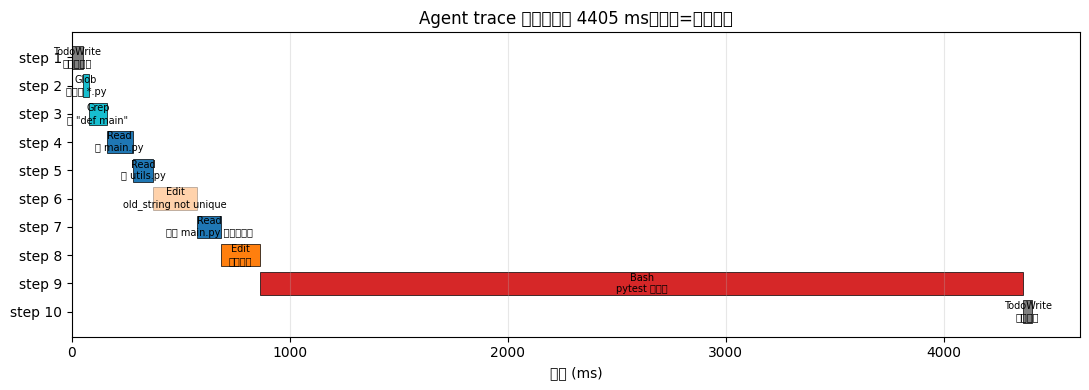

In [5]:
# 画甘特图
category_color = {
    'TodoWrite': 'tab:gray',
    'Glob': 'tab:cyan', 'Grep': 'tab:cyan',
    'Read': 'tab:blue', 'Write': 'tab:orange', 'Edit': 'tab:orange',
    'Bash': 'tab:red',
}

fig, ax = plt.subplots(figsize=(11, 4))
for i, ev in enumerate(MOCK_TRACE):
    color = category_color.get(ev['tool'], 'tab:gray')
    alpha = 1.0 if ev['success'] else 0.35
    ax.barh(i, ev['duration_ms'], left=ev['start_ms'], color=color, alpha=alpha, edgecolor='black', linewidth=0.5)
    ax.text(ev['start_ms'] + ev['duration_ms']/2, i,
            f'{ev["tool"]}\n{ev["note"]}', ha='center', va='center', fontsize=7)
ax.set_xlabel('时间 (ms)')
ax.set_yticks(range(len(MOCK_TRACE)))
ax.set_yticklabels([f'step {i+1}' for i in range(len(MOCK_TRACE))])
ax.invert_yaxis()   # step 1 在最上
ax.set_title(f'Agent trace 时间线（总 {total_ms} ms；失败=半透明）')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
# 统计：工具调用次数 + 耗时占比
stats = {}
for ev in MOCK_TRACE:
    s = stats.setdefault(ev['tool'], {'count': 0, 'total_ms': 0, 'fail': 0})
    s['count'] += 1; s['total_ms'] += ev['duration_ms']
    if not ev['success']: s['fail'] += 1

print(f'{"tool":<12} {"count":>5} {"total_ms":>10} {"fail":>5} {"%time":>7}')
print('-' * 45)
for name, s in sorted(stats.items(), key=lambda x: -x[1]['total_ms']):
    pct = s['total_ms'] / total_ms * 100
    print(f'{name:<12} {s["count"]:>5} {s["total_ms"]:>10} {s["fail"]:>5} {pct:>6.1f}%')

print('\n看 trace 的 3 个关键问题：')
print('  1. Bash 占了 80%+ 时间 → 这是 LLM agent 里典型「外部工具吃延迟」的形态')
print('  2. Read 被调了 3 次（其中 1 次是重读）→ 是否应该上下文 cache？')
print('  3. Edit 失败 1 次后重读再编辑 → 这是 Claude Code 的「自动恢复」典范')

tool         count   total_ms  fail   %time
---------------------------------------------
Bash             1       3500     0   79.5%
Edit             2        380     1    8.6%
Read             3        325     0    7.4%
TodoWrite        2         90     0    2.0%
Grep             1         80     0    1.8%
Glob             1         30     0    0.7%

看 trace 的 3 个关键问题：
  1. Bash 占了 80%+ 时间 → 这是 LLM agent 里典型「外部工具吃延迟」的形态
  2. Read 被调了 3 次（其中 1 次是重读）→ 是否应该上下文 cache？
  3. Edit 失败 1 次后重读再编辑 → 这是 Claude Code 的「自动恢复」典范


## 4. 把它套到 25 号 / 26 号 notebook 的 trace 上

下面这段函数把任意 ReAct trace 转成上面的甘特图格式。**生产 Agent 应内置类似 visualize 接口**，debug 时一键画图。

C:\Users\ril\AppData\Local\Temp\ipykernel_8368\2502479424.py:26: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\2502479424.py:26: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\2502479424.py:26: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\2502479424.py:26: UserWarning: Glyph 31639 (\N{CJK UNIFIED IDEOGRAPH-7B97}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\2502479424.py:26: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ril\AppData\Local\Temp\ipykernel_8368\250

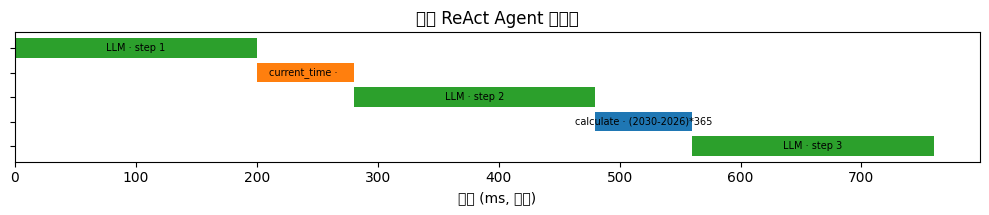

In [7]:
def trace_to_gantt(trace: list[dict], title: str = 'Agent trace'):
    """接受 [{'step': i, 'llm': '...', 'action': {...}, 'observation': '...'}] 格式。"""
    events = []
    t = 0
    for step in trace:
        # LLM 推理
        events.append({'tool': 'LLM', 'start_ms': t, 'duration_ms': 200, 'note': f'step {step["step"]}'})
        t += 200
        action = step.get('action')
        if action:
            events.append({'tool': action['tool'], 'start_ms': t, 'duration_ms': 80, 'note': action['input'][:20]})
            t += 80
    fig, ax = plt.subplots(figsize=(10, 0.5 + len(events) * 0.35))
    cmap = plt.colormaps.get_cmap('tab10')
    tools = list({e['tool'] for e in events})
    color_for = {tool: cmap(i % 10) for i, tool in enumerate(tools)}
    for i, e in enumerate(events):
        ax.barh(i, e['duration_ms'], left=e['start_ms'], color=color_for[e['tool']])
        ax.text(e['start_ms'] + e['duration_ms']/2, i, f'{e["tool"]} · {e["note"]}',
                ha='center', va='center', fontsize=7)
    ax.set_yticks(range(len(events)))
    ax.set_yticklabels([''] * len(events))
    ax.invert_yaxis()
    ax.set_xlabel('时间 (ms, 估算)')
    ax.set_title(title)
    plt.tight_layout(); plt.show()

# 假构造一个 25 号风格的 trace 跑一下
sample_trace = [
    {'step': 1, 'llm': '...', 'action': {'tool': 'current_time', 'input': ''}, 'observation': '2026-06-04 14:00:00'},
    {'step': 2, 'llm': '...', 'action': {'tool': 'calculate',    'input': '(2030-2026)*365'}, 'observation': '1460'},
    {'step': 3, 'llm': '...'},  # Final answer
]
trace_to_gantt(sample_trace, '示例 ReAct Agent 甘特图')

## 5. 你能从 Claude Code 学到什么 —— 6 条迁移到自研 Agent 的设计点

1. **工具命名用动词 + 名词**（`Read`、`Bash`、`AskUserQuestion`），LLM 一眼能懂
2. **同类工具拆细**（Read / Write / Edit）而非塞一个大工具 —— LLM 选错概率小
3. **副作用 vs 读取要分类挂权限**
4. **「问用户」要工具化** —— `AskUserQuestion` 显式触发，不靠 LLM 自由插话
5. **耗 context 子任务用 spawn sub-agent**（Claude Code 的 `Agent` 工具）
6. **TodoWrite 这种「让 Agent 管理自身任务列表」是稳定性大杀器** —— 强迫 LLM 把「想做什么」拆解出来，避免遗忘

## 深入思考

1. **`Agent` 工具的本质价值是什么？**
   - **上下文隔离**。主 Agent 不想让子任务的 100 个文件读出来污染它的 200k 上下文。子 Agent 跑完只回一段摘要。**这是 Claude Code 高质量回答的关键设计之一**。
2. **为什么 `Bash` 这个工具如此通用却只在做特殊事时才用？**
   - Claude Code 显式说「dedicated tools over Bash」—— 即使 Bash 万能，Read / Grep / Edit 等专用工具**更可控、更可缓存、更易权限管理**。
3. **`TodoWrite` 是个隐形的 Planner**
   - 它不像 LangGraph 那样显式 plan-then-execute，但**强迫 LLM 把任务拆出来**，效果近似。**门槛低、收益高**。
4. **`AskUserQuestion` 为什么单独工具化？**
   - 让「问用户」成为可观测、可计费、可限频的动作。不工具化 = LLM 想问就问 → 用户被骚扰；工具化 = 设上限可控。
5. **怎么把这些迁到自研 Agent？**
   - 抄设计哲学，不是抄代码。**重要的是：你自己的 Agent 也应该有「sub-agent / ask-user / todo / plan-mode」这几类机制**。

**改一改**：
- 把 `MOCK_TRACE` 改成一个**故意陷入死循环**的 case（连续 5 个 Read 同一文件），画甘特图直观看出问题
- 加一个 `Agent` 工具到 trace 里（duration 通常很长，因为是 spawn 子 Agent）

## 自检 ✅

- [ ] 列出 Claude Code 工具的 6 大分类（file / search / exec / agent / skill / sched）
- [ ] 解释「Read / Write / Edit 为什么分三个工具」
- [ ] 解释「sub-agent 用上下文隔离换什么」
- [ ] 给一份 Agent trace，能看出（a）耗时大头（b）失败重试模式
- [ ] 把 Claude Code 设计哲学的 6 条复述给同事

## 下一步

进入 Stage 2 → [`../stage2_进阶/28_multi_tool_memory_budget.ipynb`](../stage2_进阶/28_multi_tool_memory_budget.ipynb)